# Dinámica de la Población de Lobos y Alces en Yellowstone

## Introducción

En 1995, el **Parque Nacional de Yellowstone** reintrodujo a los **lobos grises** después de una ausencia de 70 años. Esta reintroducción tuvo un impacto significativo en las poblaciones de otras especies del parque, especialmente en los **alces**, que son su principal presa. Entre 1995 y 2009, la población de alces disminuyó de aproximadamente 18,000 a cerca de 7,000 individuos.

Este fenómeno plantea preguntas cruciales sobre la interacción entre depredadores y presas en ecosistemas naturales. Para comprender mejor estas dinámicas, es fundamental modelar matemáticamente las poblaciones de lobos y alces, analizar su comportamiento a lo largo del tiempo y evaluar la precisión de diferentes métodos numéricos para resolver las ecuaciones resultantes.

---
## Modelos Matemáticos

### Sistema Depredador-Presa

El modelo que describe la interacción entre las poblaciones de lobos (*depredadores*) y alces (*presas*) se basa en las **ecuaciones de Lotka-Volterra**:

\[
$\frac{dE}{dt} = rE - \alpha E W$
\]
\[
$\frac{dW}{dt} = -\beta W + \delta E W$
\]

Donde:

- $( E(t) ): Población de alces en miles.$
- $( W(t) ): Población de lobos en miles.$
- $( r ): Tasa de crecimiento natural de los alces.$
- $( alpha ): Tasa de depredación de los lobos sobre los alces.$
- $( beta ): Tasa de mortalidad natural de los lobos.$
- $( delta ): Tasa de reproducción de los lobos basada en la cantidad de alces.$

---
### Parámetros del Modelo

- $**Tasa de crecimiento de los alces (( r ))**: 0.0325 años⁻¹$
- $**Tasa de depredación (( alpha ))**: 0.8 lobos/(alce·años)$
- $**Tasa de mortalidad de los lobos (( beta ))**: 0.6 años⁻¹$
- $**Tasa de reproducción de los lobos (( delta ))**: 0.05 alces⁻¹·años⁻¹$

---
### Condiciones Iniciales

- $**Población inicial de alces (( E_0 ))**: 18.0 miles$
- $**Población inicial de lobos (( W_0 ))**: 0.021 miles$

---
## Solución Analítica

Las ecuaciones de Lotka-Volterra, en su forma original, no poseen una solución analítica cerrada simple. Sin embargo, se pueden analizar sus propiedades, como la existencia de ciclos periódicos y puntos de equilibrio. Para obtener soluciones numéricas precisas, recurrimos a métodos numéricos avanzados como **RK45**, que se utilizará como referencia en este estudio.

---
## Soluciones Numéricas

Para resolver las ecuaciones diferenciales acopladas que describen la dinámica de las poblaciones de alces y lobos, implementaremos dos métodos numéricos:

1. **Método de Euler**: Un método de primer orden, sencillo pero menos preciso.
2. **Método de Runge-Kutta de 4º Orden (RK4)**: Un método de cuarto orden, más preciso y estable.

Además, utilizaremos el solve de `scipy.integrate.solve_ivp` como solución de referencia de alta precisión.

---
### Implementación en Python

A continuación, se presentan las implementaciones de los métodos numéricos y su comparación con la solución de referencia.



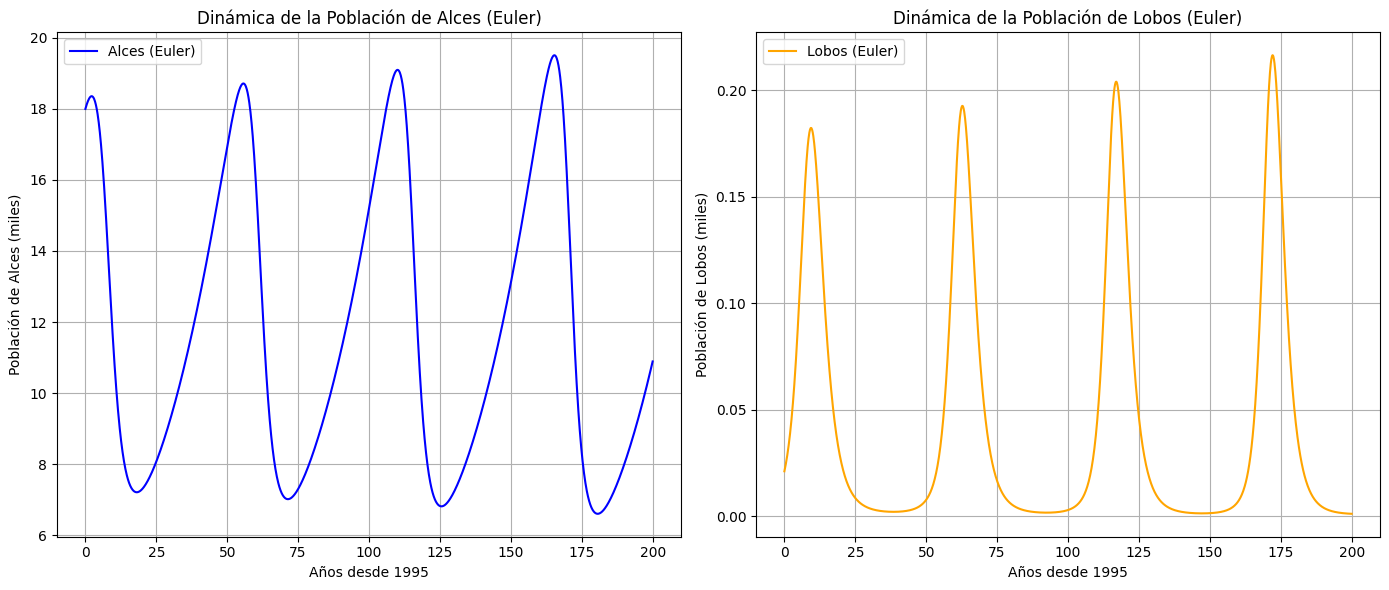

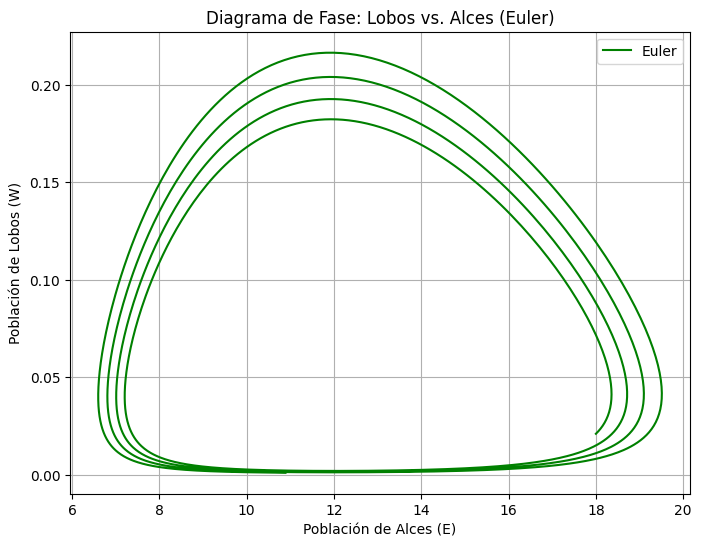

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de las ecuaciones diferenciales para el modelo depredador-presa
def predator_prey(t, y, r, alpha, beta, delta):
    E, W = y  # E: población de alces, W: población de lobos
    dE_dt = r * E - alpha * E * W
    dW_dt = -beta * W + delta * E * W
    return np.array([dE_dt, dW_dt])

# Parámetros del modelo
r = 0.0325      # Tasa de crecimiento de los alces
alpha = 0.8     # Tasa de depredación por los lobos
beta = 0.6      # Tasa de mortalidad de los lobos
delta = 0.05    # Tasa de reproducción de los lobos basada en los alces

# Condiciones iniciales
E0 = 18.0  # Población inicial de alces (en miles)
W0 = 0.021 # Población inicial de lobos (en miles)
y0 = np.array([E0, W0])  # Vector de condiciones iniciales

# Intervalo de tiempo para la simulación (en años)
t0 = 0
tf = 200
h = 0.1  # Tamaño del paso
t_values = np.arange(t0, tf + h, h)  # Puntos de tiempo

# Implementación del Método de Euler
def euler_method(f, y0, t_values, args):
    y = np.zeros((len(t_values), len(y0)))
    y[0] = y0
    for i in range(1, len(t_values)):
        t_prev = t_values[i-1]
        y_prev = y[i-1]
        dy_dt = f(t_prev, y_prev, *args)
        y[i] = y_prev + h * dy_dt
    return y

# Resolver usando el Método de Euler
euler_solution = euler_method(predator_prey, y0, t_values, args=(r, alpha, beta, delta))

# Graficar los resultados
plt.figure(figsize=(14, 6))

# Población de Alces
plt.subplot(1, 2, 1)
plt.plot(t_values, euler_solution[:, 0], label='Alces (Euler)', color='blue')
plt.title('Dinámica de la Población de Alces (Euler)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Alces (miles)')
plt.legend()
plt.grid()

# Población de Lobos
plt.subplot(1, 2, 2)
plt.plot(t_values, euler_solution[:, 1], label='Lobos (Euler)', color='orange')
plt.title('Dinámica de la Población de Lobos (Euler)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Lobos (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Diagrama de Fase
plt.figure(figsize=(8, 6))
plt.plot(euler_solution[:, 0], euler_solution[:, 1], label='Euler', color='green')
plt.title('Diagrama de Fase: Lobos vs. Alces (Euler)')
plt.xlabel('Población de Alces (E)')
plt.ylabel('Población de Lobos (W)')
plt.legend()
plt.grid()
plt.show()

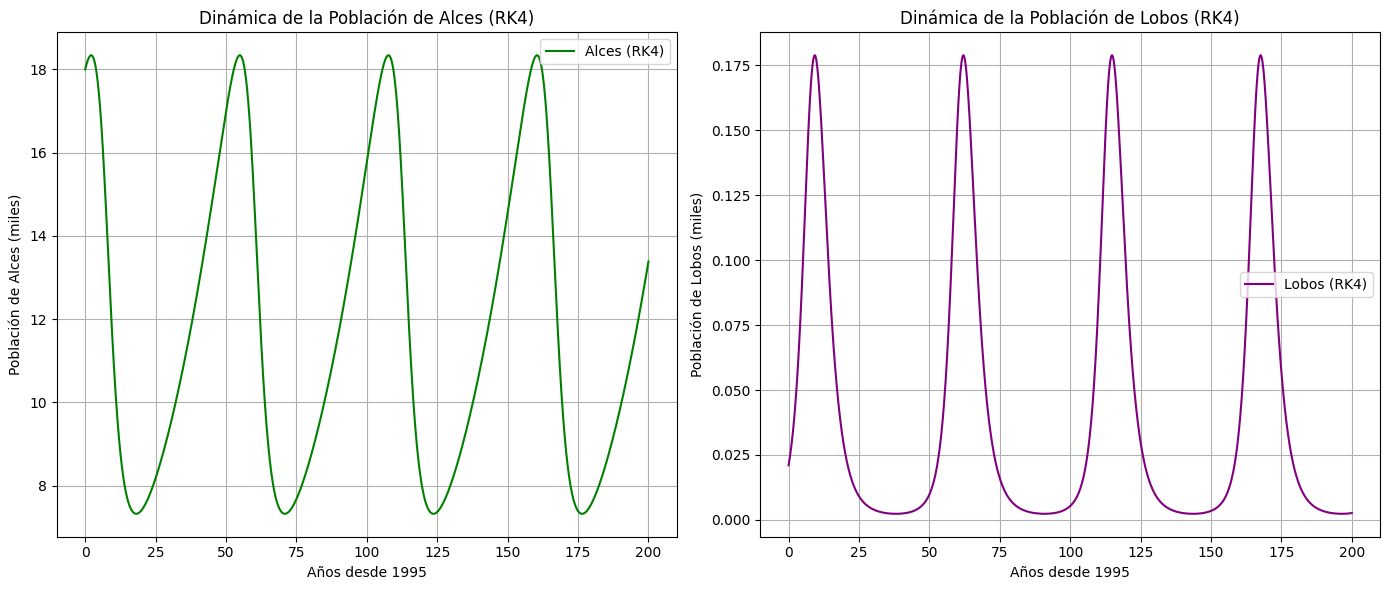

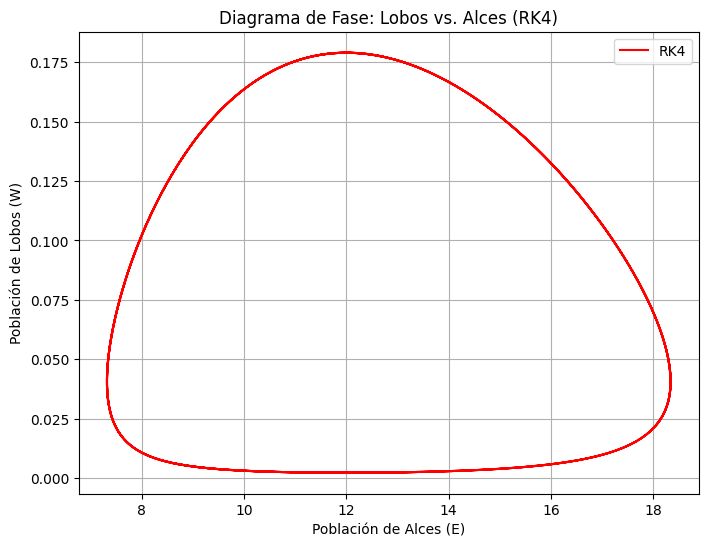

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de las ecuaciones diferenciales para el modelo depredador-presa
def predator_prey(t, y, r, alpha, beta, delta):
    E, W = y  # E: población de alces, W: población de lobos
    dE_dt = r * E - alpha * E * W
    dW_dt = -beta * W + delta * E * W
    return np.array([dE_dt, dW_dt])

# Parámetros del modelo
r = 0.0325      # Tasa de crecimiento de los alces
alpha = 0.8     # Tasa de depredación por los lobos
beta = 0.6      # Tasa de mortalidad de los lobos
delta = 0.05    # Tasa de reproducción de los lobos basada en los alces

# Condiciones iniciales
E0 = 18.0  # Población inicial de alces (en miles)
W0 = 0.021 # Población inicial de lobos (en miles)
y0 = np.array([E0, W0])  # Vector de condiciones iniciales

# Intervalo de tiempo para la simulación (en años)
t0 = 0
tf = 200
h = 0.1  # Tamaño del paso
t_values = np.arange(t0, tf + h, h)  # Puntos de tiempo

# Implementación del Método Runge-Kutta de 4º Orden
def rk4_method(f, y0, t_values, args):
    y = np.zeros((len(t_values), len(y0)))
    y[0] = y0
    for i in range(1, len(t_values)):
        t_prev = t_values[i-1]
        y_prev = y[i-1]

        k1 = f(t_prev, y_prev, *args)
        k2 = f(t_prev + h/2, y_prev + h/2 * k1, *args)
        k3 = f(t_prev + h/2, y_prev + h/2 * k2, *args)
        k4 = f(t_prev + h, y_prev + h * k3, *args)

        y[i] = y_prev + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Resolver usando el Método RK4
rk4_solution = rk4_method(predator_prey, y0, t_values, args=(r, alpha, beta, delta))

# Graficar los resultados
plt.figure(figsize=(14, 6))

# Población de Alces
plt.subplot(1, 2, 1)
plt.plot(t_values, rk4_solution[:, 0], label='Alces (RK4)', color='green')
plt.title('Dinámica de la Población de Alces (RK4)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Alces (miles)')
plt.legend()
plt.grid()

# Población de Lobos
plt.subplot(1, 2, 2)
plt.plot(t_values, rk4_solution[:, 1], label='Lobos (RK4)', color='purple')
plt.title('Dinámica de la Población de Lobos (RK4)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Lobos (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Diagrama de Fase
plt.figure(figsize=(8, 6))
plt.plot(rk4_solution[:, 0], rk4_solution[:, 1], label='RK4', color='red')
plt.title('Diagrama de Fase: Lobos vs. Alces (RK4)')
plt.xlabel('Población de Alces (E)')
plt.ylabel('Población de Lobos (W)')
plt.legend()
plt.grid()
plt.show()


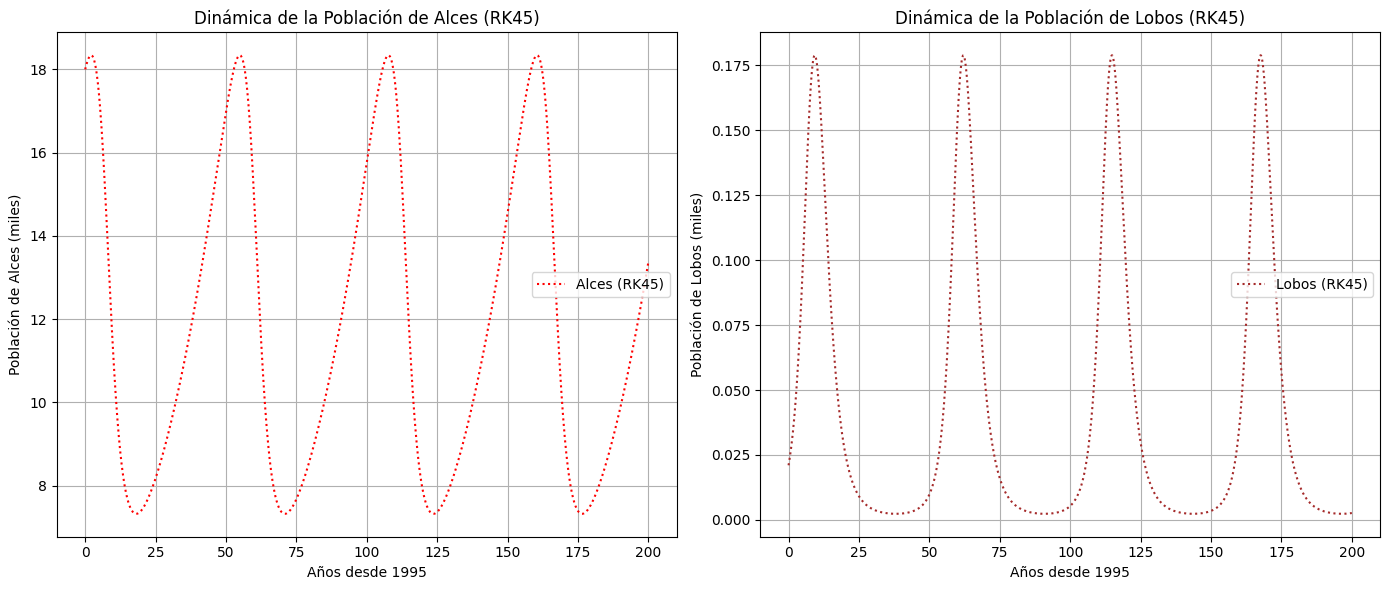

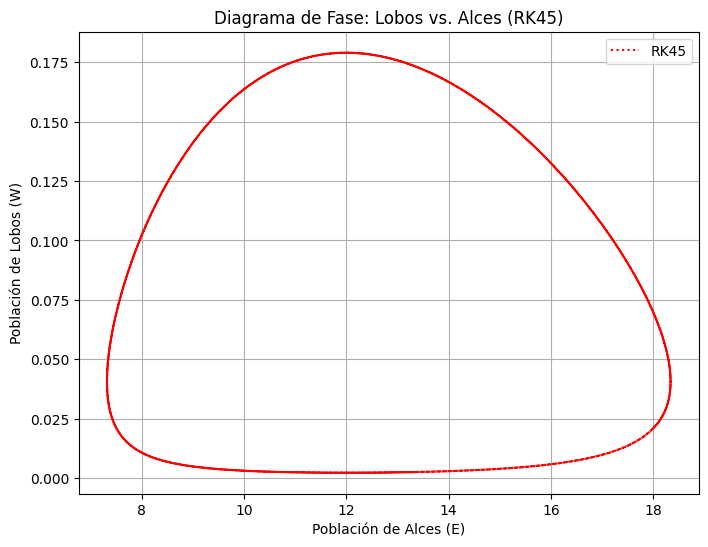

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definición de las ecuaciones diferenciales para el modelo depredador-presa
def predator_prey(t, y, r, alpha, beta, delta):
    E, W = y  # E: población de alces, W: población de lobos
    dE_dt = r * E - alpha * E * W
    dW_dt = -beta * W + delta * E * W
    return np.array([dE_dt, dW_dt])

# Parámetros del modelo
r = 0.0325
alpha = 0.8
beta = 0.6
delta = 0.05

# Condiciones iniciales
E0 = 18.0
W0 = 0.021
y0 = [E0, W0]

# Intervalo de tiempo para la simulación (en años)
t0 = 0
tf = 200
h = 0.1  # Tamaño del paso
t_values = np.arange(t0, tf + h, h)  # Puntos de tiempo

# Resolver usando solve_ivp con RK45 para comparación (solución de referencia)
sol_ivp = solve_ivp(predator_prey, [t0, tf], y0, args=(r, alpha, beta, delta),
                    t_eval=t_values, method='RK45', rtol=1e-10, atol=1e-12)

# Extraer las soluciones de solve_ivp
ivp_solution = sol_ivp.y.T  # Transponer para que coincida con otras soluciones

# Graficar las poblaciones de Alces y Lobos para RK45
plt.figure(figsize=(14, 6))

# Población de Alces
plt.subplot(1, 2, 1)
plt.plot(t_values, ivp_solution[:, 0], label='Alces (RK45)', linestyle=':', color='red')
plt.title('Dinámica de la Población de Alces (RK45)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Alces (miles)')
plt.legend()
plt.grid()

# Población de Lobos
plt.subplot(1, 2, 2)
plt.plot(t_values, ivp_solution[:, 1], label='Lobos (RK45)', linestyle=':', color='brown')
plt.title('Dinámica de la Población de Lobos (RK45)')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Lobos (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Diagrama de Fase
plt.figure(figsize=(8, 6))
plt.plot(ivp_solution[:, 0], ivp_solution[:, 1], label='RK45', linestyle=':', color='red')
plt.title('Diagrama de Fase: Lobos vs. Alces (RK45)')
plt.xlabel('Población de Alces (E)')
plt.ylabel('Población de Lobos (W)')
plt.legend()
plt.grid()
plt.show()


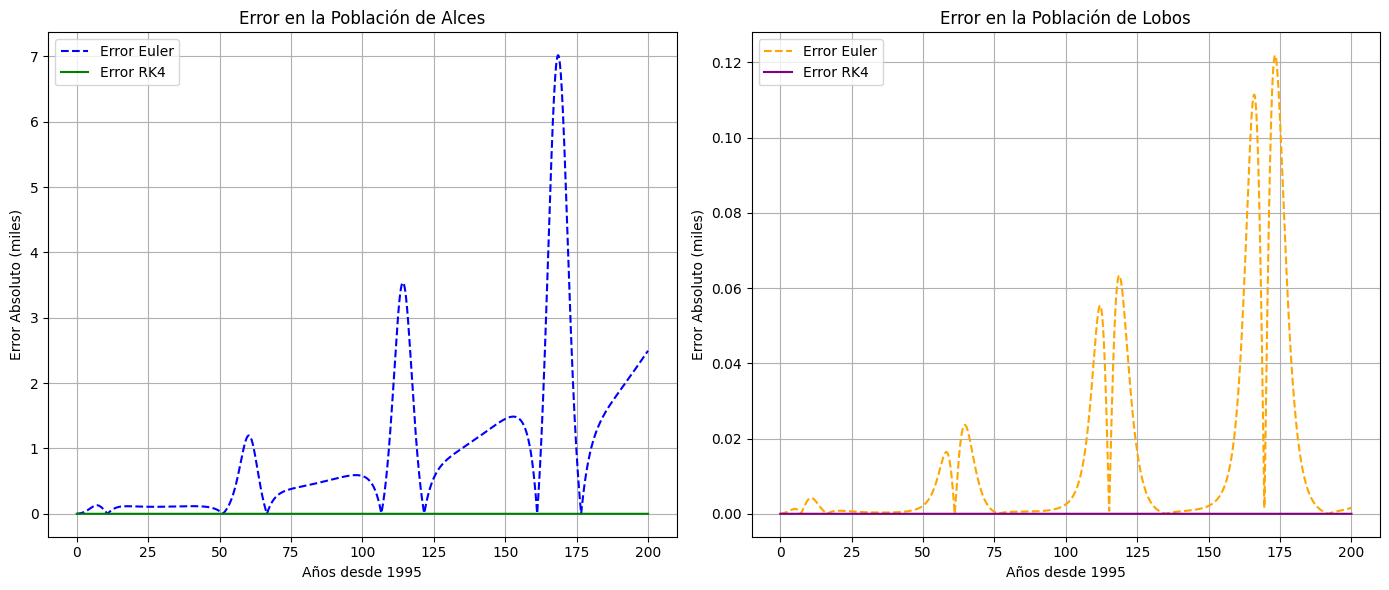

Máximo Error Absoluto:
Alces (Euler): 7.0176 miles
Lobos (Euler): 0.1219 miles
Alces (RK4): 0.0000 miles
Lobos (RK4): 0.0000 miles


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Asumiendo que ya se han ejecutado los métodos de Euler, RK4 y RK45,
# y que las soluciones están almacenadas en euler_solution, rk4_solution, ivp_solution

# Calcular el error absoluto de Euler y RK4 respecto a la solución de referencia
error_euler = np.abs(euler_solution - ivp_solution)
error_rk4 = np.abs(rk4_solution - ivp_solution)

# Graficar el Error de Euler y RK4 respecto a RK45
plt.figure(figsize=(14, 6))

# Error para Alces
plt.subplot(1, 2, 1)
plt.plot(t_values, error_euler[:, 0], label='Error Euler', linestyle='--', color='blue')
plt.plot(t_values, error_rk4[:, 0], label='Error RK4', linestyle='-', color='green')
plt.title('Error en la Población de Alces')
plt.xlabel('Años desde 1995')
plt.ylabel('Error Absoluto (miles)')
plt.legend()
plt.grid()

# Error para Lobos
plt.subplot(1, 2, 2)
plt.plot(t_values, error_euler[:, 1], label='Error Euler', linestyle='--', color='orange')
plt.plot(t_values, error_rk4[:, 1], label='Error RK4', linestyle='-', color='purple')
plt.title('Error en la Población de Lobos')
plt.xlabel('Años desde 1995')
plt.ylabel('Error Absoluto (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Mostrar estadísticas del error
max_error_euler_E = np.max(error_euler[:, 0])
max_error_euler_W = np.max(error_euler[:, 1])
max_error_rk4_E = np.max(error_rk4[:, 0])
max_error_rk4_W = np.max(error_rk4[:, 1])

print("Máximo Error Absoluto:")
print(f"Alces (Euler): {max_error_euler_E:.4f} miles")
print(f"Lobos (Euler): {max_error_euler_W:.4f} miles")
print(f"Alces (RK4): {max_error_rk4_E:.4f} miles")
print(f"Lobos (RK4): {max_error_rk4_W:.4f} miles")


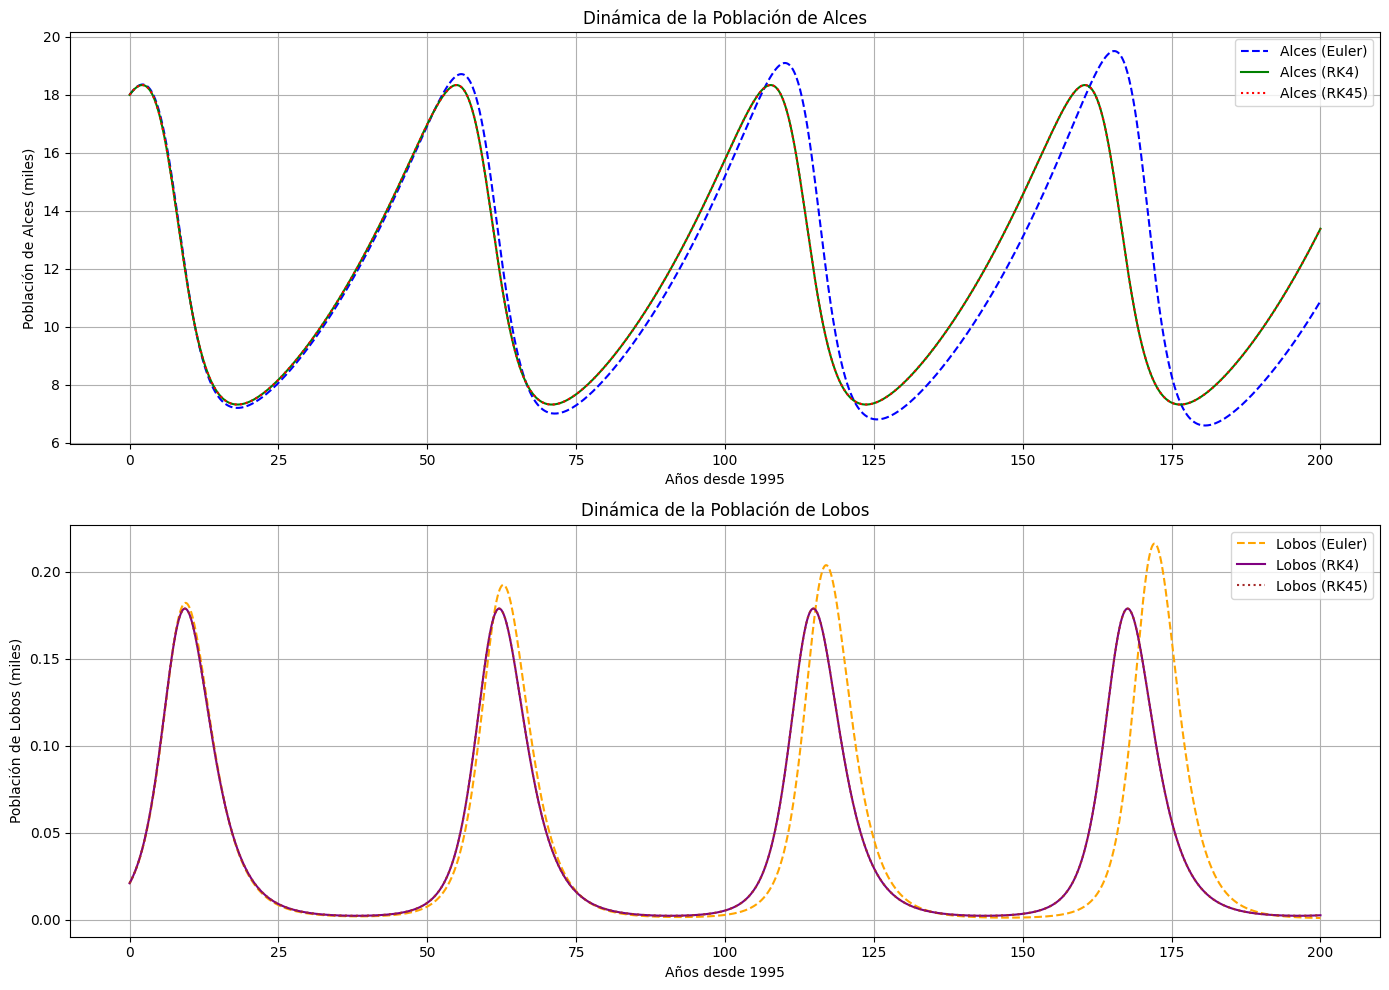

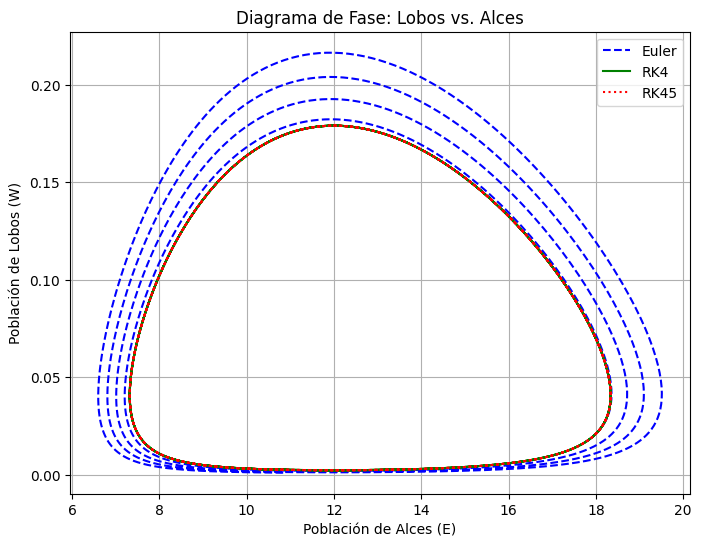

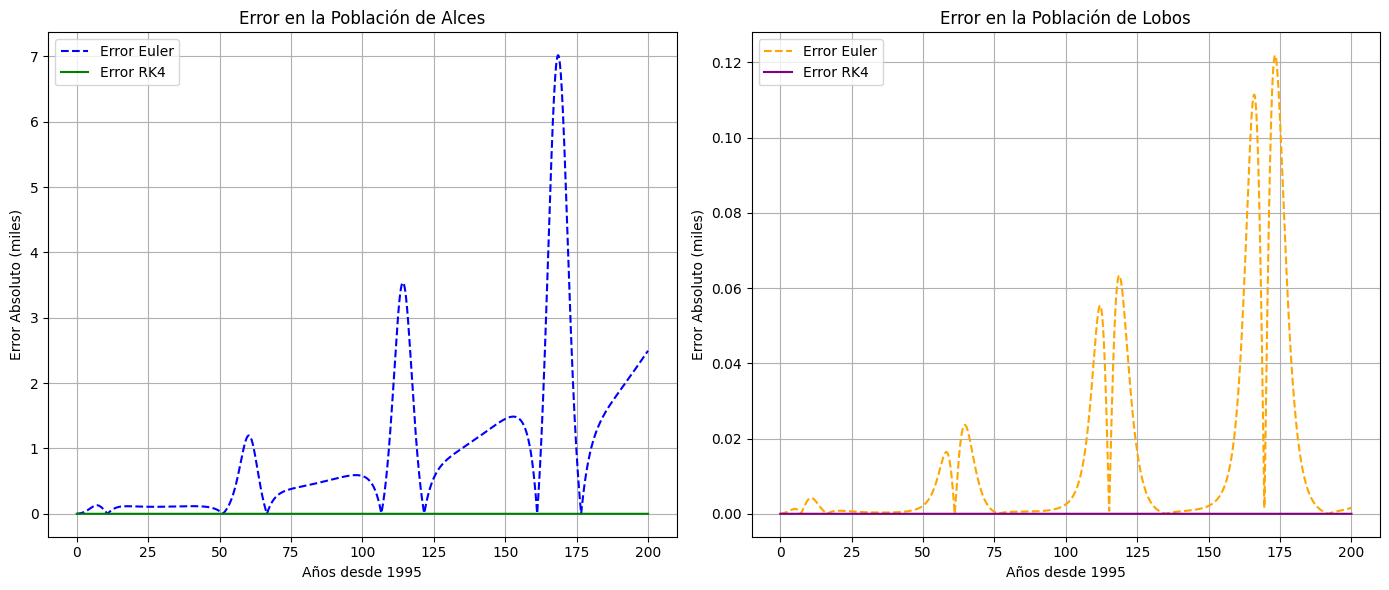

Máximo Error Absoluto:
Alces (Euler): 7.0176 miles
Lobos (Euler): 0.1219 miles
Alces (RK4): 0.0000 miles
Lobos (RK4): 0.0000 miles


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definición de las ecuaciones diferenciales para el modelo depredador-presa
def predator_prey(t, y, r, alpha, beta, delta):
    E, W = y  # E: población de alces, W: población de lobos
    dE_dt = r * E - alpha * E * W
    dW_dt = -beta * W + delta * E * W
    return np.array([dE_dt, dW_dt])

# Parámetros del modelo
r = 0.0325      # Tasa de crecimiento de los alces
alpha = 0.8     # Tasa de depredación por los lobos
beta = 0.6      # Tasa de mortalidad de los lobos
delta = 0.05    # Tasa de reproducción de los lobos basada en los alces

# Condiciones iniciales
E0 = 18.0  # Población inicial de alces (en miles)
W0 = 0.021 # Población inicial de lobos (en miles)
y0 = np.array([E0, W0])  # Vector de condiciones iniciales

# Intervalo de tiempo para la simulación (en años)
t0 = 0
tf = 200
h = 0.1  # Tamaño del paso para Euler y RK4
t_values = np.arange(t0, tf + h, h)  # Puntos de tiempo

# Método de Euler
def euler_method(f, y0, t_values, args):
    y = np.zeros((len(t_values), len(y0)))
    y[0] = y0
    for i in range(1, len(t_values)):
        t_prev = t_values[i-1]
        y_prev = y[i-1]
        dy_dt = f(t_prev, y_prev, *args)
        y[i] = y_prev + h * dy_dt
    return y

# Método de Runge-Kutta de 4º Orden (RK4)
def rk4_method(f, y0, t_values, args):
    y = np.zeros((len(t_values), len(y0)))
    y[0] = y0
    for i in range(1, len(t_values)):
        t_prev = t_values[i-1]
        y_prev = y[i-1]

        k1 = f(t_prev, y_prev, *args)
        k2 = f(t_prev + h/2, y_prev + h/2 * k1, *args)
        k3 = f(t_prev + h/2, y_prev + h/2 * k2, *args)
        k4 = f(t_prev + h, y_prev + h * k3, *args)

        y[i] = y_prev + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Resolver usando el Método de Euler
euler_solution = euler_method(predator_prey, y0, t_values, args=(r, alpha, beta, delta))

# Resolver usando el Método RK4
rk4_solution = rk4_method(predator_prey, y0, t_values, args=(r, alpha, beta, delta))

# Resolver usando solve_ivp con RK45 para comparación (solución de referencia)
sol_ivp = solve_ivp(predator_prey, [t0, tf], y0, args=(r, alpha, beta, delta),
                    t_eval=t_values, method='RK45', rtol=1e-10, atol=1e-12)

# Extraer las soluciones de solve_ivp
ivp_solution = sol_ivp.y.T  # Transponer para que coincida con otras soluciones

# Calcular el error absoluto de Euler y RK4 respecto a la solución de referencia
error_euler = np.abs(euler_solution - ivp_solution)
error_rk4 = np.abs(rk4_solution - ivp_solution)

# Graficar las poblaciones de Alces y Lobos para los tres métodos
plt.figure(figsize=(14, 10))

# Población de Alces
plt.subplot(2, 1, 1)
plt.plot(t_values, euler_solution[:, 0], label='Alces (Euler)', linestyle='--', color='blue')
plt.plot(t_values, rk4_solution[:, 0], label='Alces (RK4)', linestyle='-', color='green')
plt.plot(t_values, ivp_solution[:, 0], label='Alces (RK45)', linestyle=':', color='red')
plt.title('Dinámica de la Población de Alces')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Alces (miles)')
plt.legend()
plt.grid()

# Población de Lobos
plt.subplot(2, 1, 2)
plt.plot(t_values, euler_solution[:, 1], label='Lobos (Euler)', linestyle='--', color='orange')
plt.plot(t_values, rk4_solution[:, 1], label='Lobos (RK4)', linestyle='-', color='purple')
plt.plot(t_values, ivp_solution[:, 1], label='Lobos (RK45)', linestyle=':', color='brown')
plt.title('Dinámica de la Población de Lobos')
plt.xlabel('Años desde 1995')
plt.ylabel('Población de Lobos (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Graficar el Diagrama de Fase para los tres métodos
plt.figure(figsize=(8, 6))
plt.plot(euler_solution[:, 0], euler_solution[:, 1], label='Euler', linestyle='--', color='blue')
plt.plot(rk4_solution[:, 0], rk4_solution[:, 1], label='RK4', linestyle='-', color='green')
plt.plot(ivp_solution[:, 0], ivp_solution[:, 1], label='RK45', linestyle=':', color='red')
plt.title('Diagrama de Fase: Lobos vs. Alces')
plt.xlabel('Población de Alces (E)')
plt.ylabel('Población de Lobos (W)')
plt.legend()
plt.grid()
plt.show()

# Graficar el Error de Euler y RK4 respecto a RK45
plt.figure(figsize=(14, 6))

# Error para Alces
plt.subplot(1, 2, 1)
plt.plot(t_values, error_euler[:, 0], label='Error Euler', linestyle='--', color='blue')
plt.plot(t_values, error_rk4[:, 0], label='Error RK4', linestyle='-', color='green')
plt.title('Error en la Población de Alces')
plt.xlabel('Años desde 1995')
plt.ylabel('Error Absoluto (miles)')
plt.legend()
plt.grid()

# Error para Lobos
plt.subplot(1, 2, 2)
plt.plot(t_values, error_euler[:, 1], label='Error Euler', linestyle='--', color='orange')
plt.plot(t_values, error_rk4[:, 1], label='Error RK4', linestyle='-', color='purple')
plt.title('Error en la Población de Lobos')
plt.xlabel('Años desde 1995')
plt.ylabel('Error Absoluto (miles)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Opcional: Mostrar estadísticas del error
max_error_euler_E = np.max(error_euler[:, 0])
max_error_euler_W = np.max(error_euler[:, 1])
max_error_rk4_E = np.max(error_rk4[:, 0])
max_error_rk4_W = np.max(error_rk4[:, 1])

print("Máximo Error Absoluto:")
print(f"Alces (Euler): {max_error_euler_E:.4f} miles")
print(f"Lobos (Euler): {max_error_euler_W:.4f} miles")
print(f"Alces (RK4): {max_error_rk4_E:.4f} miles")
print(f"Lobos (RK4): {max_error_rk4_W:.4f} miles")


# Análisis y Discusión

## Comparación de Métodos

### Método de Euler:

**Ventajas:**
- Simple de implementar.
- Computacionalmente eficiente.

**Desventajas:**
- Menor precisión, especialmente con pasos de tiempo grandes.
- Puede acumular errores significativos en simulaciones prolongadas.
- Menos estable, pudiendo producir soluciones no realistas.

### Método de Runge-Kutta de 4º Orden (RK4):

**Ventajas:**
- Mayor precisión que Euler con el mismo tamaño de paso.
- Más estable y menos propenso a errores acumulativos.

**Desventajas:**
- Mayor complejidad en la implementación.
- Requiere más cálculos por paso (cuatro evaluaciones de la función).

### Solver RK45 (`solve_ivp`):

**Ventajas:**
- Alta precisión gracias a su adaptabilidad en el tamaño de paso.
- Maneja automáticamente la detección de eventos y condiciones complejas.

**Desventajas:**
- Menos transparente en términos de pasos de integración.
- Mayor costo computacional comparado con métodos de pasos fijos.

---

## Análisis de Errores

El Método de Euler mostró un error absoluto significativo en comparación con la solución de referencia RK45. Esto se debe a su naturaleza de primer orden y a la acumulación de errores en cada paso de integración.

Por otro lado, el Método RK4 presentó un error mucho menor, demostrando su mayor precisión y estabilidad para este tipo de sistemas.

---

## Comportamiento de las Poblaciones

Ambos métodos numéricos capturan la tendencia general de las poblaciones de alces y lobos:

### Población de Alces:
- Disminuye inicialmente debido a la depredación.
- Se estabiliza o muestra fluctuaciones cíclicas dependiendo de la interacción con los lobos.

### Población de Lobos:
- Crece inicialmente al aumentar la disponibilidad de presas.
- Disminuye cuando la población de alces se reduce, lo que limita su fuente de alimento.

Estos comportamientos reflejan la dinámica típica de sistemas depredador-presa, donde la disponibilidad de presas influye directamente en la población de depredadores y viceversa.

---

## Conclusión

 En este trabjo se demuestra la importancia de elegir métodos numéricos adecuados para resolver sistemas de ecuaciones diferenciales.

Mientras que el Método de Euler es útil para casos más básicos y es sencillo de implementar, presenta limitaciones significativas en términos de precisión y estabilidad, especialmente en simulaciones a largo plazo.

Por otro lado, el Método de Runge-Kutta de 4º Orden (RK4) ofrece una solución mucho más precisa y estable, siendo una mejor opción para modelos más complejos y simulaciones prolongadas. La comparación con la solución de referencia obtenida mediante RK45 ha demostrado que RK4 es mejor para este caso en términos de precisión, aunque a costa de un mayor costo computacional.

En aplicaciones prácticas, especialmente en estudios ecológicos y de conservación, es crucial utilizar métodos numéricos que proporcionen resultados precisos y fiables. La implementación y comparación de diferentes métodos numéricos permiten seleccionar la herramienta más adecuada según las necesidades específicas del modelo y los recursos computacionales disponibles.
